In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


# Step 2 - Data Loading

In [2]:
#____________________________ part a and b ______________________________#
import os
import pandas as pd
import rarfile
import zipfile
import tempfile
from khayyam import JalaliDate

if not os.path.exists('Hamshahri-Corpus.csv'):
    archive_path = "/media/nima/E6D643D9D643A91F/MSc/term2/applied_machine_learning/TA/HW/codes/hamshahri.rar"
    zip_file_path = "hamshahriold/Corpus/Hamshahri-Corpus.zip"
    txt_file_path = "Hamshahri-Corpus.txt"
    separator = "\t"

    # Open the main RAR archive
    with rarfile.RarFile(archive_path, 'r') as rar:
        # Extract the ZIP file to a temporary location
        with tempfile.TemporaryDirectory() as tmp_dir:
            rar.extract(zip_file_path, tmp_dir)

            # Read the contents of the text file from the extracted ZIP
            with zipfile.ZipFile(f"{tmp_dir}/{zip_file_path}", 'r') as zip_ref:
                with zip_ref.open(txt_file_path, 'r') as txt_file:
                    data = txt_file.readlines()

    # Process the lines and split them into columns using the custom separator
    lines = [line.decode('utf-8').strip().split(separator) for line in data]

    # Extract the relevant data for each sample
    samples = []
    current_sample = {}

    for line in lines:
        if line[0] == ".DID":
            # Save the previous sample
            if current_sample:
                samples.append(current_sample)
            # Reset the current sample
            current_sample = {}

        elif line[0] == ".Date":
            solar_date = line[1]
            jalali_date = JalaliDate(int('13'+solar_date[:2]), int(solar_date[3:5]), int(solar_date[6:8]))
            ad_date = jalali_date.todate().strftime("%Y-%m-%d")
            current_sample["date"] = ad_date

        elif line[0] == ".Cat":
            current_sample["category"] = line[1]

        else:
            if "text" not in current_sample:
                current_sample["text"] = line[0]
            else:
                current_sample["text"] += " " + line[0]

    # Add the last sample after the loop ends
    if current_sample:
        samples.append(current_sample)

    # Create the dataframe
    df = pd.DataFrame(samples, columns=["text", "category", "date"])

    # Save the DataFrame to a CSV file
    df.to_csv('Hamshahri-Corpus.csv', sep=',')

# Load the CSV file into a new DataFrame
data = pd.read_csv('Hamshahri-Corpus.csv')
data.drop(columns=['Unnamed: 0'],inplace=True)
print(data)
data


                                                     text category        date
0       جاودانگي در زندگي گروهي از طريق هنر نگاهي به ن...    adabh  1996-06-22
1       رويدادهاي هنري جهان نمايشگاه هنر در خدمت ديكتا...    adabh  1996-06-22
2       برديوار نگارخانه ها گالري گلستان: نمايشگاه طرح...    adabh  1996-06-22
3       بازي را جدي بگيريم مطالعه اي مقدماتي پيرامون ن...    ejtem  1996-06-22
4       تخته سياه و غباري كه سترده نمي شود... اشاره; ب...    elmfa  1996-06-22
...                                                   ...      ...         ...
165220  نماينده فدراسيون جهاني واليبال از ايران هر نظر...    vrzsh  2003-02-09
165221  شكست نامداران تكواندودر پيكارهاي برتر ليگ گروه...    vrzsh  2003-02-09
165222  ورزشگاه بزرگ دانشگاه آزاد در تهران ساخته مي شو...    vrzsh  2003-02-09
165223  رئيس فدراسيون پزشكي انتخاب شد گروه ورزشي: مجمع...    vrzsh  2003-02-09
165224  نتايج هفته يازدهم وزنه برداري باشگاهها گروه ور...    vrzsh  2003-02-09

[165225 rows x 3 columns]


,text,category,date
0,جاودانگي در زندگي گروهي از طريق هنر نگاهي به ن...,adabh,1996-06-22
1,رويدادهاي هنري جهان نمايشگاه هنر در خدمت ديكتا...,adabh,1996-06-22
2,برديوار نگارخانه ها گالري گلستان: نمايشگاه طرح...,adabh,1996-06-22
3,بازي را جدي بگيريم مطالعه اي مقدماتي پيرامون ن...,ejtem,1996-06-22
4,تخته سياه و غباري كه سترده نمي شود... اشاره; ب...,elmfa,1996-06-22
...,...,...,...
165220,نماينده فدراسيون جهاني واليبال از ايران هر نظر...,vrzsh,2003-02-09
165221,شكست نامداران تكواندودر پيكارهاي برتر ليگ گروه...,vrzsh,2003-02-09
165222,ورزشگاه بزرگ دانشگاه آزاد در تهران ساخته مي شو...,vrzsh,2003-02-09
165223,رئيس فدراسيون پزشكي انتخاب شد گروه ورزشي: مجمع...,vrzsh,2003-02-09


# Step 3 - Data Visualization

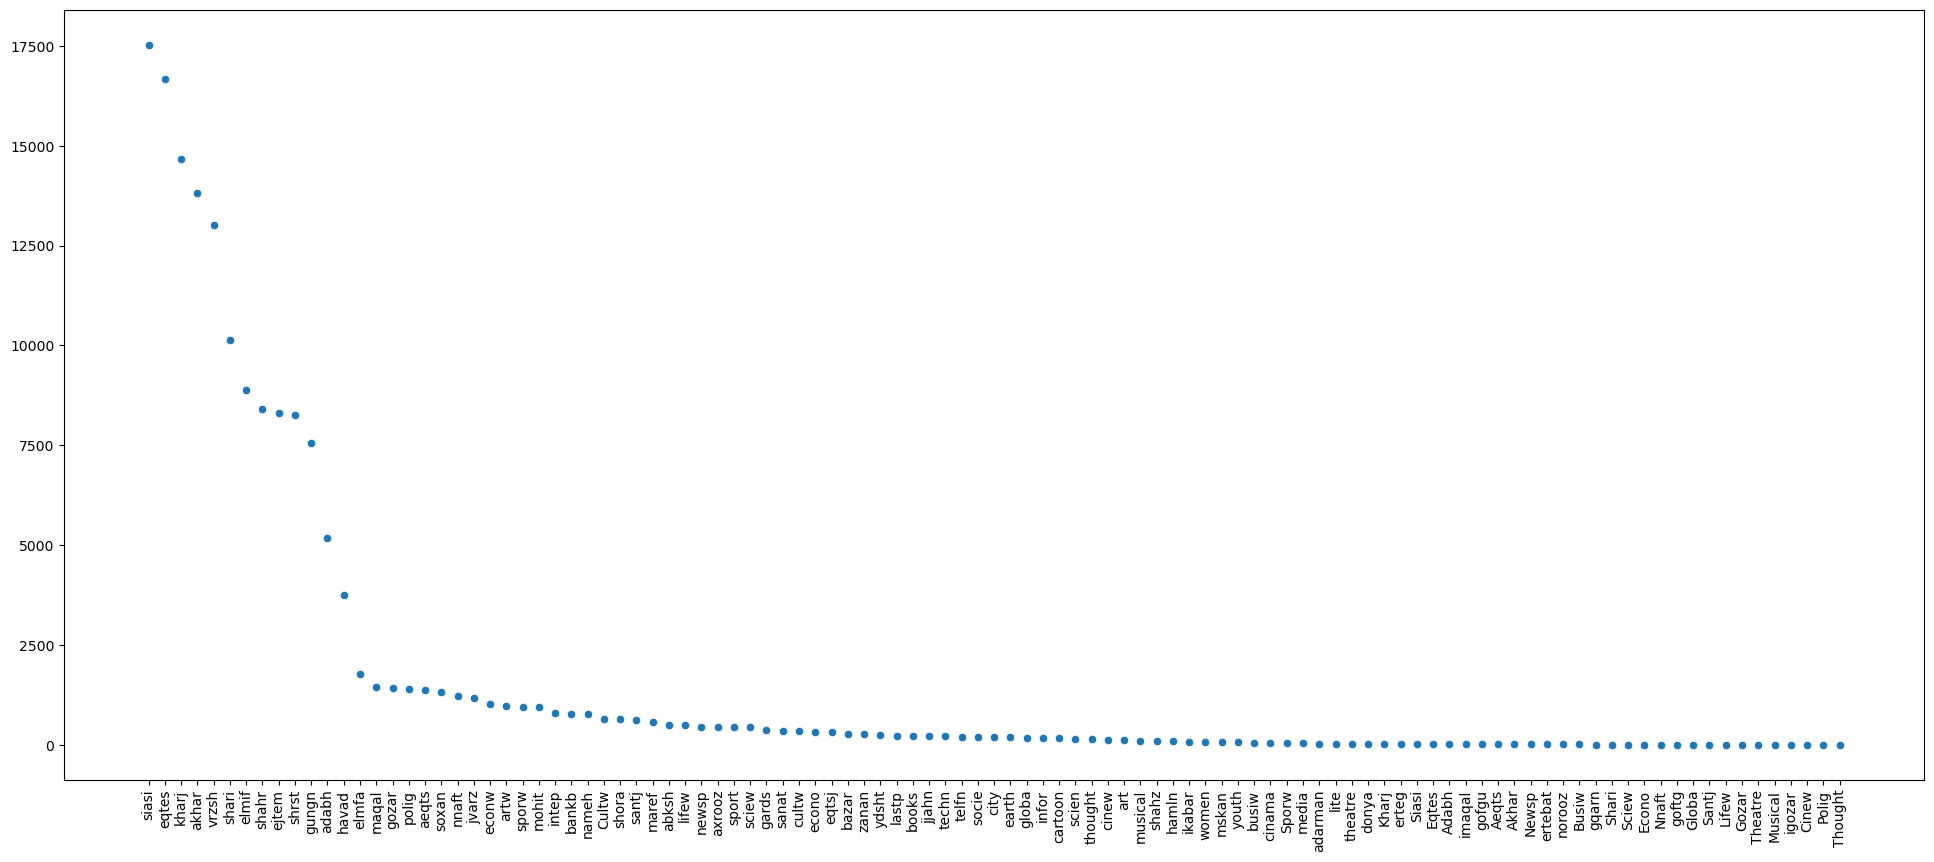

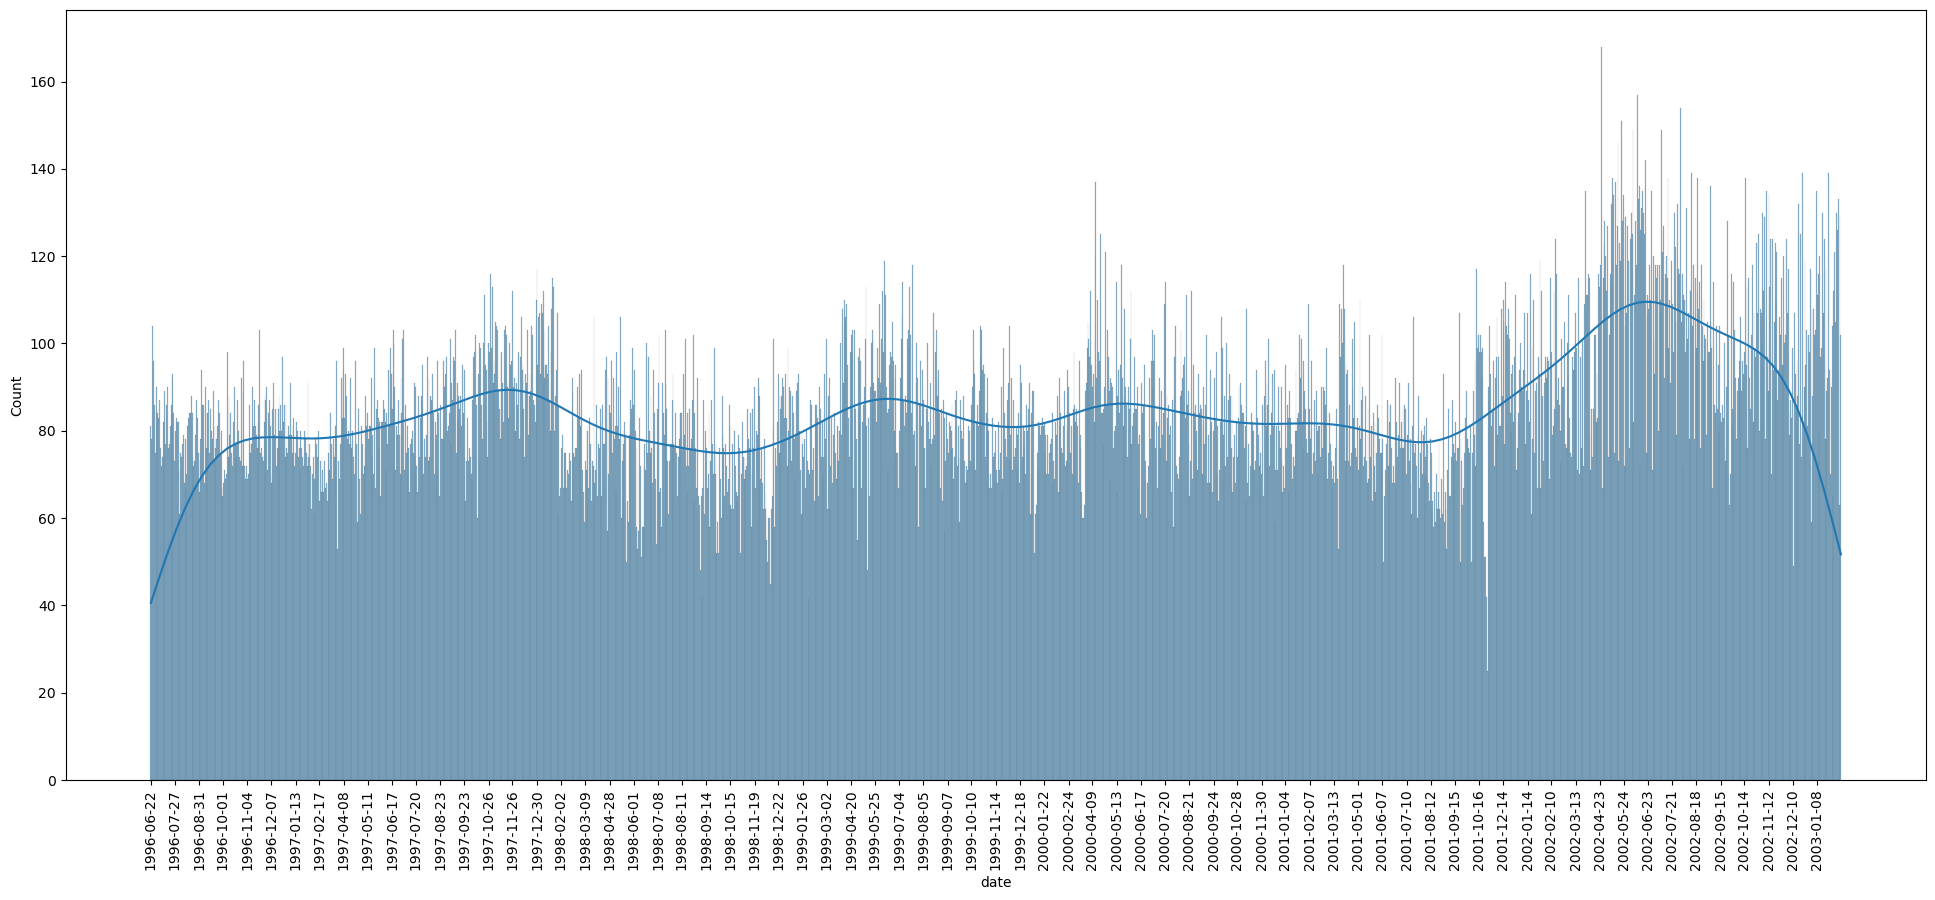

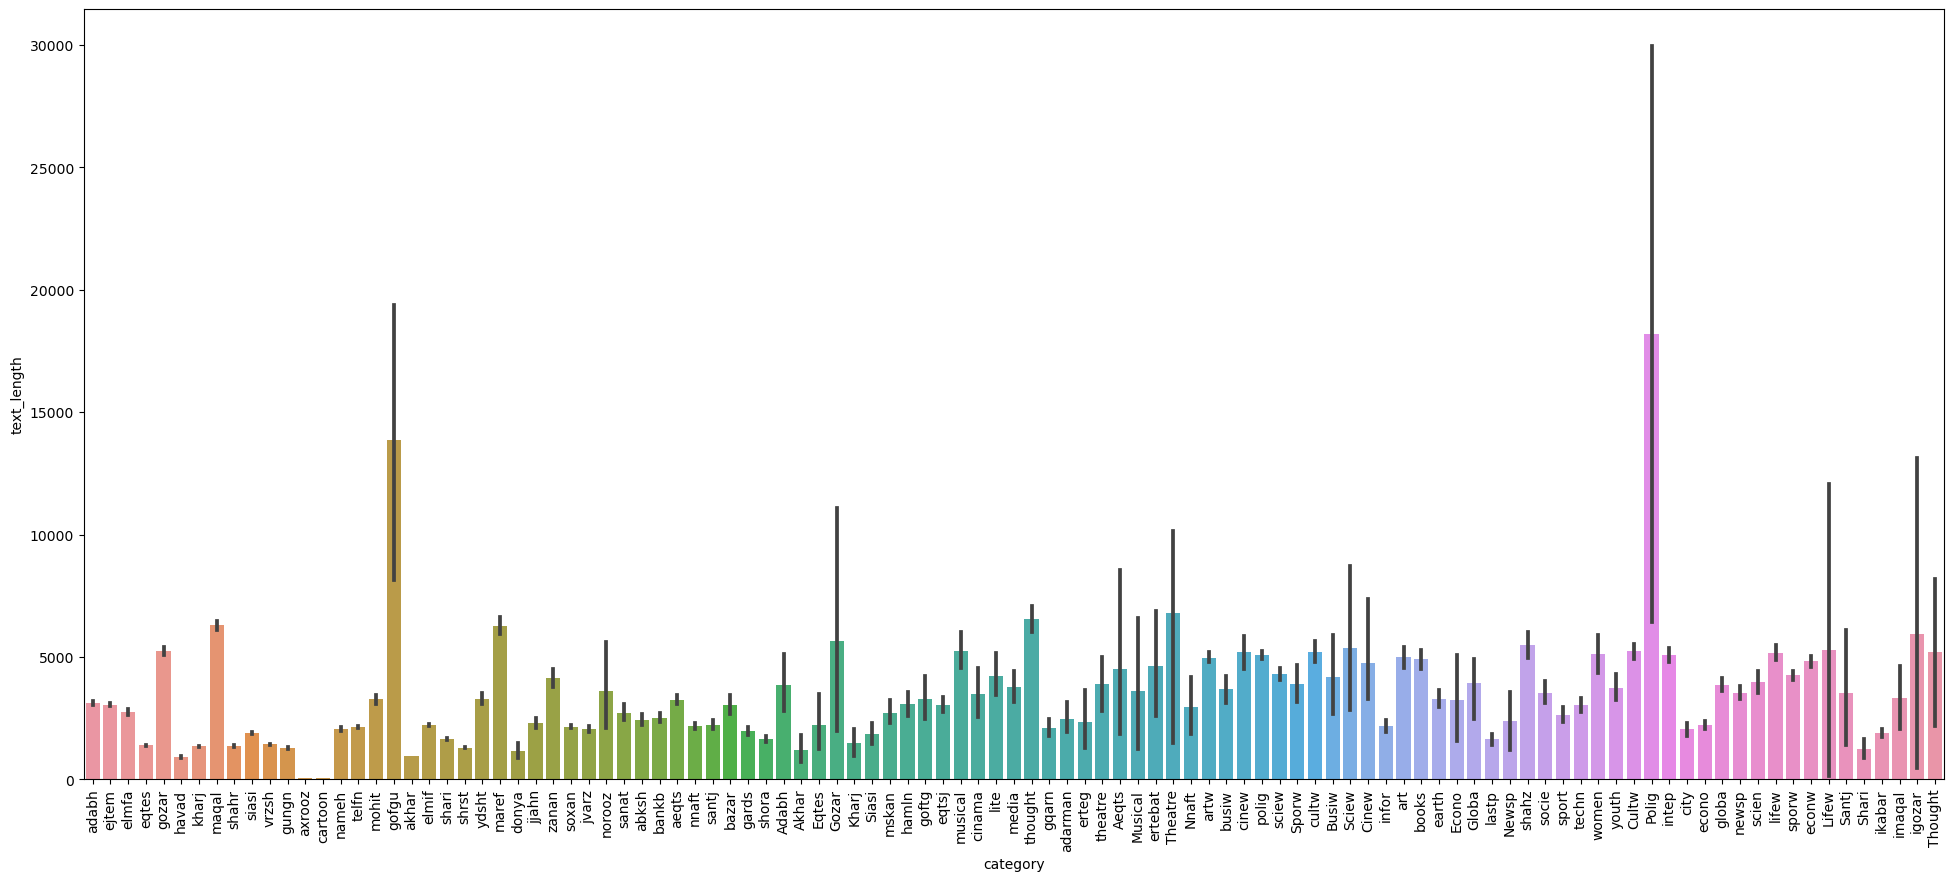

In [3]:
#____________________________ part a ______________________________#
import matplotlib.pyplot as plt 
import seaborn as sns 

_=plt.figure(figsize=(24, 10))
#_=sns.histplot(data['category'],kde=True)
_=sns.scatterplot(x=data['category'].value_counts().index, y=data['category'].value_counts().values)
_=plt.xticks(rotation='vertical')

num_of_labels=70
number_of_unique_dates = data['date'].unique().shape[0]
date_values = [int(i*number_of_unique_dates/num_of_labels) for i in range(num_of_labels)]
_=plt.figure(figsize=(24, 10))
_=sns.histplot(data['date'],kde=True)
_=plt.xticks(date_values, rotation='vertical')

# Add the 'len' column to the dataframe
data['text_length'] = data['text'].apply(lambda x: len(x))

_=plt.figure(figsize=(24, 10))
_=sns.barplot(x=data['category'], y=data['text_length'])
_=plt.xticks(rotation="vertical")

data.drop(columns=['text_length'],inplace=True)

plt.show()


# Step 4 – Preprocessing

In [4]:
#____________________________ part a ______________________________#
import re
import hazm 

# Count the number of NaN values in each column
nan_counts = data.isna().sum()

# Print the NaN counts for each column
print(nan_counts)

# Count the frequencies of each category
category_counts = data['category'].value_counts()

# Get the six most frequent categories
top_categories = category_counts.nlargest(6).index.tolist()

# Filter the DataFrame to keep only the rows with the top categories
data = data.loc[data['category'].isin(top_categories)].copy()

# Set the display option to show all rows
pd.set_option('display.max_rows', None)

print(data['date'].value_counts())
print(data['category'].value_counts())

# Reset the display option to the default value
pd.reset_option('display.max_rows')

def remove_tags(string):
    removelist = ""
    result = re.sub('<.*?>', '', string)   #remove HTML tags
    result = re.sub('http\S+', '', result)  #remove URLs
    result = re.sub(r'[^\w\s'+removelist+']', ' ', result, flags=re.UNICODE)   #remove non-alphanumeric characters 
    result = result.lower()
    return result

stop_words = ['/','؟','.','«','»','>','<',':','؛','!','٪','،',')','(','ـ','-','=','+','*']
data['text'] = data['text'].apply(lambda x: remove_tags(x))
data['text'] = data['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

lemmatizer = hazm.Lemmatizer()

def lemmatize_text(text):
    st = ""
    for w in hazm.word_tokenize(text):
        st = st + lemmatizer.lemmatize(w) + " "
    return st

data['text'] = data['text'].apply(lemmatize_text)
data


text        0
category    0
date        0
dtype: int64
2001-04-11    86
2001-04-10    81
1999-07-22    76
2000-04-13    76
2001-04-12    76
2000-04-20    74
2000-04-17    74
1999-05-13    74
2000-04-04    73
1999-06-12    73
1999-06-10    72
2001-01-24    71
2000-04-27    71
1999-07-07    71
2000-03-30    71
1999-06-24    71
2001-04-24    71
1999-08-26    70
2001-05-10    70
2000-10-17    70
2001-09-20    70
1999-07-20    70
1999-10-25    69
1999-07-29    69
2000-11-01    69
1998-04-05    69
2000-04-12    69
1999-04-11    69
1999-06-01    69
2000-04-03    69
2001-04-07    69
1999-06-21    68
1999-05-24    68
2002-08-22    68
2000-09-20    68
2001-04-26    68
1999-06-03    68
1999-07-19    67
2000-07-25    67
2000-08-14    67
2000-08-15    67
2000-04-18    67
2000-11-09    67
1998-07-21    67
1999-10-21    67
2001-04-17    67
2000-07-19    67
2000-05-18    66
2001-05-15    66
2000-10-31    66
2000-04-23    66
2000-07-20    66
1999-07-18    66
2000-08-27    66
1998-05-14    66
1999-06-08

,text,category,date
10,رشد اقتصادي كشورهاي صنعتي در سال آينده سازمان ...,eqtes,1996-06-22
11,تن 44 از مديران ارشد 16 كشور در تهران آموزش دي...,eqtes,1996-06-22
12,كميته راهنمايي سرمايه گذار ايراني تشكيل مي شد#...,eqtes,1996-06-22
13,هفته صرفه جويي در مصرف آب آغاز شد#شو سرويس اقت...,eqtes,1996-06-22
14,كاهش مجدد مازاد بازرگاني ژاپن واحد رسانه هاي خ...,eqtes,1996-06-22
...,...,...,...
165220,نماينده فدراسيون جهاني واليبال از ايران هر نظر...,vrzsh,2003-02-09
165221,شكست نامدار تكواندودر پيكارهاي برتر ليگ گروه و...,vrzsh,2003-02-09
165222,ورزشگاه بزرگ دانشگاه آزاد در تهران ساخته مي شد...,vrzsh,2003-02-09
165223,رئيس فدراسيون پزشكي انتخاب شد#شو گروه ورزشي مج...,vrzsh,2003-02-09


# Step 5 - Feature Engineering

In [5]:
#____________________________ part a ______________________________#
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np 

# TF-IDF calculation
vectorizer = TfidfVectorizer()

# Fit the vectorizer on the text data
tfidf_matrix = vectorizer.fit_transform(data['text'])

# Get the feature names (keywords)
keywords = vectorizer.get_feature_names_out()

# Extract keywords for each row and store them in the 'keywords' column
data['keywords'] = [', '.join([keywords[idx] for idx in idxs.indices]) if len(idxs.indices) > 0 else '' for idxs in tfidf_matrix]

# Extract important sentences for each row and store them in the 'important_sentences' column
data['important_sentences'] = [' '.join([sentence for sentence in sentences.split('. ') if any(keyword in sentence for keyword in keywords.split(', '))]) if len(sentences) > 0 else '' for sentences, keywords in zip(data['text'], data['keywords'])]

# Reset the index
data.reset_index(drop=True, inplace=True)

# Print the updated DataFrame
data


,text,category,date,keywords,important_sentences
0,رشد اقتصادي كشورهاي صنعتي در سال آينده سازمان ...,eqtes,1996-06-22,"بيشتر, نيز, آلمان, فرانسه, دار, افزايش, 4ژاپن,...",رشد اقتصادي كشورهاي صنعتي در سال آينده سازمان ...
1,تن 44 از مديران ارشد 16 كشور در تهران آموزش دي...,eqtes,1996-06-22,"التحصيل, فارغ, ها, ازاين, زيادي, تعداد, جمهوري...",تن 44 از مديران ارشد 16 كشور در تهران آموزش دي...
2,كميته راهنمايي سرمايه گذار ايراني تشكيل مي شد#...,eqtes,1996-06-22,"گيرد, قرار, توليد, خط, توليدي, طرح, اجرايي, عم...",كميته راهنمايي سرمايه گذار ايراني تشكيل مي شد#...
3,هفته صرفه جويي در مصرف آب آغاز شد#شو سرويس اقت...,eqtes,1996-06-22,"الگوي, هفتم, اقتصاد, ششم, آباداني, پنجم, شرب, ...",هفته صرفه جويي در مصرف آب آغاز شد#شو سرويس اقت...
4,كاهش مجدد مازاد بازرگاني ژاپن واحد رسانه هاي خ...,eqtes,1996-06-22,"آمد, پايين, 40, قريب, حساس, بسيار, سياسي, هم, ...",كاهش مجدد مازاد بازرگاني ژاپن واحد رسانه هاي خ...
...,...,...,...,...,...
85820,نماينده فدراسيون جهاني واليبال از ايران هر نظر...,vrzsh,2003-02-09,"آگوستاو, بازديدهايم, مناسبخواندن, توانستيم, لو...",نماينده فدراسيون جهاني واليبال از ايران هر نظر...
85821,شكست نامدار تكواندودر پيكارهاي برتر ليگ گروه و...,vrzsh,2003-02-09,"مويدي, تكواندودر, هسا, نامدار, تكواندو, اندام,...",شكست نامدار تكواندودر پيكارهاي برتر ليگ گروه و...
85822,ورزشگاه بزرگ دانشگاه آزاد در تهران ساخته مي شد...,vrzsh,2003-02-09,"وخوابگاه, پونك, فوتسال, واترپلو, گنجايش, بدنسا...",ورزشگاه بزرگ دانشگاه آزاد در تهران ساخته مي شد...
85823,رئيس فدراسيون پزشكي انتخاب شد#شو گروه ورزشي مج...,vrzsh,2003-02-09,"كسبراي, خليليان, خشايار, مهرزاد, 4مدت, ماخوذه,...",رئيس فدراسيون پزشكي انتخاب شد#شو گروه ورزشي مج...


<Figure size 1200x600 with 0 Axes>

(array([ 9496.,  9862., 10227., 10592., 10957., 11323., 11688., 12053.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

Text(0.5, 0, 'Time Interval')

Text(0, 0.5, 'Frequency')

Text(0.5, 1.0, 'Frequency of "NATO" Over Time')

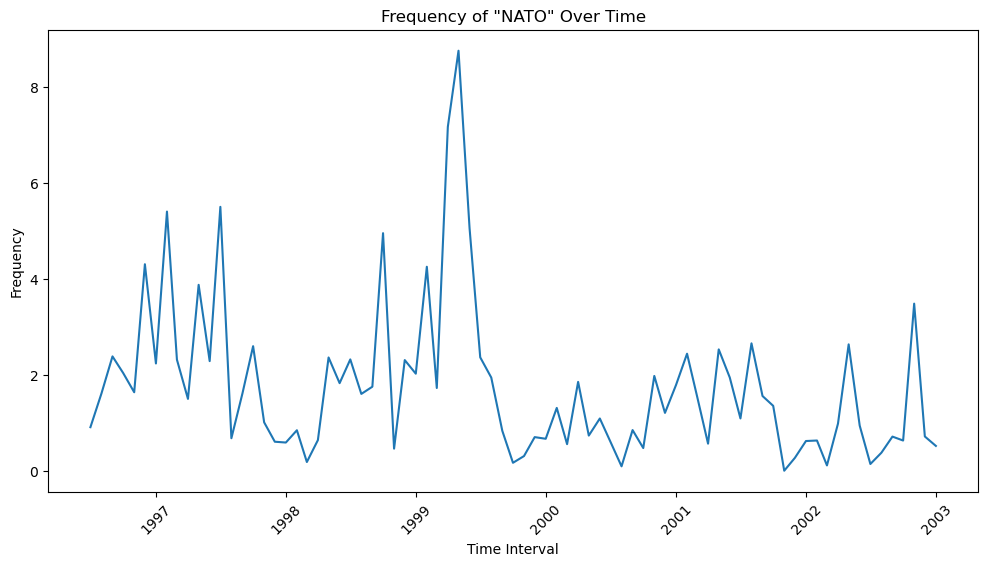

In [6]:
#____________________________ part b ______________________________#

# Convert 'date' column to datetime data type
data['date'] = pd.to_datetime(data['date'])

# Filter data to include dates up to 2004
filtered_data = data[data['date'].dt.year <= 2004]

# Create time intervals
start_date = filtered_data['date'].min()
end_date = filtered_data['date'].max()
interval = pd.date_range(start=start_date, end=end_date, freq='M')

# Get the indices of documents within each time interval
indices = filtered_data.groupby(pd.cut(filtered_data['date'], bins=interval)).indices

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer()
tfidf_vectors = tfidf.fit_transform(filtered_data['text'])

# Get the indices of the word \"ناتو\" in the TF-IDF vocabulary
word_index = tfidf.vocabulary_.get('ناتو', -1)

# Calculate the frequency of the word \"ناتو\" in each time interval
frequency_data = []
for interval_index in indices:
    interval_documents = tfidf_vectors[indices[interval_index], word_index]
    word_frequency = interval_documents.sum()
    frequency_data.append(word_frequency)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(interval[:-1], frequency_data)
plt.xticks(rotation=45)
plt.xlabel('Time Interval')
plt.ylabel('Frequency')
plt.title('Frequency of "NATO" Over Time')
plt.show()


# Step 6 - Dimensionality Reduction

In [7]:
#____________________________ part a ______________________________#
from sklearn.decomposition import TruncatedSVD

# Preprocess the text data using TF-IDF vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['text'])

# Apply Truncated SVD to reduce dimensionality to 2
n_components = 2
svd = TruncatedSVD(n_components=n_components)
X_svd = svd.fit_transform(X)

# Create a new dataframe with reduced dimensions
df_reduced = pd.DataFrame(X_svd, columns=['PC1', 'PC2'])

df_reduced


,PC1,PC2
0,0.246198,-0.062654
1,0.305993,-0.041611
2,0.324517,-0.050714
3,0.139969,-0.010006
4,0.160960,-0.022675
...,...,...
85820,0.314145,0.125093
85821,0.155700,0.171475
85822,0.285350,0.168229
85823,0.175186,0.043761


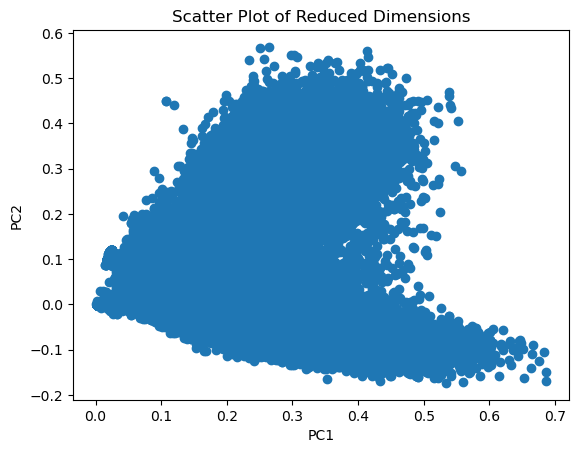

In [8]:
#____________________________ part b ______________________________#

# Scatter plot of the reduced dimensions
ـ=plt.scatter(df_reduced['PC1'], df_reduced['PC2'])
ـ=plt.xlabel('PC1')
ـ=plt.ylabel('PC2')
ـ=plt.title('Scatter Plot of Reduced Dimensions')

# Show the plot
ـ=plt.show()


# Step 7 - Clustering In this section, consider that the category should not be treated as data or information (unsupervised learning).

In [9]:
#____________________________ part a ______________________________#
from sklearn.cluster import KMeans

# Assuming 'df_reduced' contains the reduced dimensions dataframe

# Perform K-means clustering
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(df_reduced[['PC1', 'PC2']])


KMeans(n_clusters=6)

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'K-means Clustering (n_clusters=6)')

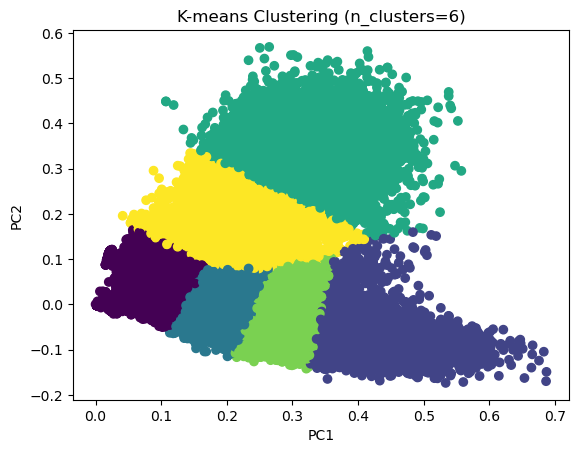

In [10]:
#____________________________ part b ______________________________#

# Get the cluster labels
cluster_labels = kmeans.labels_

# Add the cluster labels to the dataframe
df_reduced['Cluster'] = cluster_labels

# Visualize the clusters
plt.scatter(df_reduced['PC1'], df_reduced['PC2'], c=df_reduced['Cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means Clustering (n_clusters=6)')

# Show the plot
plt.show()


# Step 8 - Storage

In [11]:
#____________________________ part a ______________________________#

# Preprocess the text data using TF-IDF vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['text'])

# Apply Truncated SVD to reduce dimensionality to 5
n_components = 5
svd = TruncatedSVD(n_components=n_components)
X_svd = svd.fit_transform(X)

# Create a new dataframe with reduced dimensions
df_reduced = pd.DataFrame(X_svd, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

df_reduced


,PC1,PC2,PC3,PC4,PC5
0,0.246198,-0.062591,0.005314,0.026355,0.109878
1,0.305993,-0.041606,0.003563,0.002709,0.000789
2,0.324517,-0.050760,-0.000775,0.019626,0.069574
3,0.139969,-0.009891,0.000281,0.025365,0.061739
4,0.160960,-0.022687,0.001722,0.019265,0.069622
...,...,...,...,...,...
85820,0.314145,0.125101,0.000459,-0.026826,0.002858
85821,0.155700,0.171465,0.000706,-0.020239,0.003287
85822,0.285350,0.168251,-0.001856,-0.015318,0.022066
85823,0.175186,0.043726,0.001802,-0.003016,-0.020997


In [12]:
#____________________________ part b ______________________________#

# Perform K-means clustering
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters)
labels = kmeans.fit_predict(df_reduced)

# Add the cluster labels to the dataframe
df_reduced['label'] = labels

#print(df_reduced['label'].value_counts())

# Print the updated dataframe with the 'label' column
df_reduced


,PC1,PC2,PC3,PC4,PC5,label
0,0.246198,-0.062591,0.005314,0.026355,0.109878,3
1,0.305993,-0.041606,0.003563,0.002709,0.000789,0
2,0.324517,-0.050760,-0.000775,0.019626,0.069574,0
3,0.139969,-0.009891,0.000281,0.025365,0.061739,3
4,0.160960,-0.022687,0.001722,0.019265,0.069622,3
...,...,...,...,...,...,...
85820,0.314145,0.125101,0.000459,-0.026826,0.002858,1
85821,0.155700,0.171465,0.000706,-0.020239,0.003287,1
85822,0.285350,0.168251,-0.001856,-0.015318,0.022066,1
85823,0.175186,0.043726,0.001802,-0.003016,-0.020997,3


In [13]:
#____________________________ part c ______________________________#

df_reduced.to_csv('Hamshahri-Corpus_6cluster_5dimension.csv', sep=',')


# Step 9 - Classification (Model Building)

In [14]:
#____________________________ part b ______________________________#

df = pd.read_csv('Hamshahri-Corpus_6cluster_5dimension.csv', sep=',')

from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Assuming 'df' contains the dataframe with 5 numerical features and the 'label' column as the target

# Create the individual models
knn = KNeighborsClassifier()
log_reg = LogisticRegression(max_iter=1000)
naive_bayes = GaussianNB()
random_forest = RandomForestClassifier()

# Create the ensemble model using voting
ensemble_model = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('log_reg', log_reg),
        ('naive_bayes', naive_bayes),
        ('random_forest', random_forest)
    ],
    voting='hard'  # Use 'hard' voting for majority rule
)


# Step 10 - Preprocessing on Data

In [15]:
#____________________________ part a ______________________________#
from sklearn.preprocessing import StandardScaler 
'''
def delete_outlier(df,attr):
    Q1=df[attr].quantile(0.25)
    Q3=df[attr].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]

print(df['label'].value_counts())

for attr in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    df=delete_outlier(df,attr)
'''
df['label'] = df['label'].astype('int')

# Create a subset of the DataFrame with all features except 'salary_in_usd'
features_to_scale = df.drop('label', axis=1)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features to be scaled
scaled_features = scaler.fit_transform(features_to_scale)

# Replace the scaled features in the original DataFrame
df[features_to_scale.columns] = scaled_features

df = df.drop('Unnamed: 0', axis=1)

#print(df['label'].value_counts())

df


"\ndef delete_outlier(df,attr):\n    Q1=df[attr].quantile(0.25)\n    Q3=df[attr].quantile(0.75)\n    IQR=Q3-Q1\n    lower_limit=Q1-1.5*IQR\n    upper_limit=Q3+1.5*IQR\n    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]\n\nprint(df['label'].value_counts())\n\nfor attr in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:\n    df=delete_outlier(df,attr)\n"

,PC1,PC2,PC3,PC4,PC5,label
0,0.089494,-0.621425,-0.054522,0.145561,1.161014,3
1,0.690994,-0.427439,-0.072360,-0.114630,-0.078863,0
2,0.877333,-0.512058,-0.116535,0.071522,0.702932,0
3,-0.979098,-0.134256,-0.105785,0.134666,0.613885,3
4,-0.767945,-0.252543,-0.091108,0.067541,0.703475,3
...,...,...,...,...,...,...
85820,0.773005,1.113651,-0.103973,-0.439638,-0.055347,1
85821,-0.820859,1.542258,-0.101451,-0.367148,-0.050466,1
85822,0.483345,1.512551,-0.127547,-0.313004,0.162962,1
85823,-0.624841,0.361399,-0.090288,-0.177634,-0.326471,3


In [16]:
#____________________________ part b ______________________________#
from sklearn.model_selection import train_test_split

#print(df['label'].value_counts())

# Separate the data and target
X = df.drop('label', axis=1)
y = df['label']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

# Print the shapes of the train and test sets
print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)


Train data shape: (68660, 5)
Test data shape: (17165, 5)
Train target shape: (68660,)
Test target shape: (17165,)


# Step 11 - Model Training

In [17]:
#____________________________ part a ______________________________#

# Train each individual model
knn.fit(X_train, y_train)
log_reg.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)
random_forest.fit(X_train, y_train)


KNeighborsClassifier()

LogisticRegression(max_iter=1000)

GaussianNB()

RandomForestClassifier()

# Step 12 - Model Evaluation

In [18]:
#____________________________ part a and b ______________________________#
from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate accuracies on training data
knn_train_accuracy = accuracy_score(y_train, knn.predict(X_train))
log_reg_train_accuracy = accuracy_score(y_train, log_reg.predict(X_train))
naive_bayes_train_accuracy = accuracy_score(y_train, naive_bayes.predict(X_train))
random_forest_train_accuracy = accuracy_score(y_train, random_forest.predict(X_train))

# Calculate accuracies on testing data
knn_test_accuracy = accuracy_score(y_test, knn.predict(X_test))
log_reg_test_accuracy = accuracy_score(y_test, log_reg.predict(X_test))
naive_bayes_test_accuracy = accuracy_score(y_test, naive_bayes.predict(X_test))
random_forest_test_accuracy = accuracy_score(y_test, random_forest.predict(X_test))

# Obtain confusion matrix on testing data
knn_confusion_matrix = confusion_matrix(y_test, knn.predict(X_test))
log_reg_confusion_matrix = confusion_matrix(y_test, log_reg.predict(X_test))
naive_bayes_confusion_matrix = confusion_matrix(y_test, naive_bayes.predict(X_test))
random_forest_confusion_matrix = confusion_matrix(y_test, random_forest.predict(X_test))

# Print the accuracies and confusion matrices
print("KNN Training Accuracy:", knn_train_accuracy)
print("KNN Testing Accuracy:", knn_test_accuracy)
print("KNN Confusion Matrix:")
print(knn_confusion_matrix)
print()

print("Logistic Regression Training Accuracy:", log_reg_train_accuracy)
print("Logistic Regression Testing Accuracy:", log_reg_test_accuracy)
print("Logistic Regression Confusion Matrix:")
print(log_reg_confusion_matrix)
print()

print("Naive Bayes Training Accuracy:", naive_bayes_train_accuracy)
print("Naive Bayes Testing Accuracy:", naive_bayes_test_accuracy)
print("Naive Bayes Confusion Matrix:")
print(naive_bayes_confusion_matrix)
print()

print("Random Forest Training Accuracy:", random_forest_train_accuracy)
print("Random Forest Testing Accuracy:", random_forest_test_accuracy)
print("Random Forest Confusion Matrix:")
print(random_forest_confusion_matrix)


KNN Training Accuracy: 0.9955141275852024
KNN Testing Accuracy: 0.9926012234197495
KNN Confusion Matrix:
[[6957    1    0   50    0    0]
 [   3 1862    0    7    0    0]
 [   0    0  195    0    0    0]
 [  43   12    0 7418    6    0]
 [   1    0    0    4  439    0]
 [   0    0    0    0    0  167]]

Logistic Regression Training Accuracy: 0.9959801922516749
Logistic Regression Testing Accuracy: 0.9963297407515292
Logistic Regression Confusion Matrix:
[[6992    3    0   13    0    0]
 [   4 1867    0    1    0    0]
 [   0    0  195    0    0    0]
 [  14    9    0 7445   11    0]
 [   3    0    0    5  436    0]
 [   0    0    0    0    0  167]]

Naive Bayes Training Accuracy: 0.9120302942033207
Naive Bayes Testing Accuracy: 0.9144188756189922
Naive Bayes Confusion Matrix:
[[6802   56    0  140   10    0]
 [   0 1861    0   11    0    0]
 [   0    0  195    0    0    0]
 [1007  197    1 6232   42    0]
 [   0    0    0    5  439    0]
 [   0    0    0    0    0  167]]

Random Forest

In [19]:

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Calculate accuracy on training data
ensemble_train_accuracy = accuracy_score(y_train, ensemble_model.predict(X_train))

# Calculate accuracy on testing data
ensemble_test_accuracy = accuracy_score(y_test, ensemble_model.predict(X_test))

# Obtain confusion matrix on testing data
ensemble_confusion_matrix = confusion_matrix(y_test, ensemble_model.predict(X_test))

# Print the accuracy and confusion matrix
print("Ensemble Training Accuracy:", ensemble_train_accuracy)
print("Ensemble Testing Accuracy:", ensemble_test_accuracy)
print("Ensemble Confusion Matrix:")
print(ensemble_confusion_matrix)


VotingClassifier(estimators=[('knn', KNeighborsClassifier()),
                             ('log_reg', LogisticRegression(max_iter=1000)),
                             ('naive_bayes', GaussianNB()),
                             ('random_forest', RandomForestClassifier())])

Ensemble Training Accuracy: 0.9970725313137198
Ensemble Testing Accuracy: 0.9942907078357122
Ensemble Confusion Matrix:
[[7001    3    0    4    0    0]
 [   1 1870    0    1    0    0]
 [   0    0  195    0    0    0]
 [  58   21    0 7397    3    0]
 [   1    0    0    6  437    0]
 [   0    0    0    0    0  167]]


In [20]:
#____________________________ part e ______________________________#
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Converting target to float
y = y.astype(float)

# Training the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predicting on the test set
y_pred = model.predict(X_test)

# Calculating mean squared error (MSE) and R2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Printing the results
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


LinearRegression()

Mean Squared Error (MSE): 0.8300602872398661
R2 Score: 0.6229796006546726
